# TravelTide Mastery Project

## Segmentbasierte Rewards- und Perk-Empfehlungen

### Ziel dieses Notebooks

Im vorherigen Notebook wurden 5.752 Kunden mithilfe eines hybriden Ansatzes
in zehn Segmente unterteilt. Kunden mit besonders deutlich ausgeprägten
Verhaltensmerkmalen wurden regelbasiert segmentiert. Für die übrigen Kunden
wurden mithilfe von K-Means zusätzliche Verhaltensgruppen gebildet.

Ziel dieses Notebooks ist es, für die zehn Kundensegmente geeignete
Rewards-Benefits abzuleiten und segmentbezogene Marketingempfehlungen zu
entwickeln.

Dazu werden:

1. die finale segmentierte Kundentabelle eingelesen und kontrolliert,
2. die wichtigsten Bedürfnisse der Kundensegmente zusammengefasst,
3. geeignete Rewards-Benefits ausgewählt und begründet,
4. jedem Kunden über sein Segment ein primärer Perk zugeordnet,
5. passende Kommunikationsansätze für die einzelnen Segmente entwickelt,
6. die finale Kundentabelle mit Segment und Perk exportiert.

Neben den ursprünglich betrachteten Benefits können weitere Vorteile
vorgeschlagen werden, wenn sie sich nachvollziehbar aus dem beobachteten
Kundenverhalten ableiten lassen.

Die Empfehlungen beruhen auf historischen Verhaltensdaten und stellen keine
kausalen Wirkungsnachweise dar. Ihre tatsächliche Wirksamkeit sollte daher
nach Einführung des Rewards-Programms durch A/B-Tests oder Pilotkampagnen
überprüft werden.

## 1. Datenimport und erste Kontrolle

Als Datengrundlage wird die im vorherigen Notebook exportierte
Kundentabelle verwendet. Sie enthält alle aufbereiteten Kundenmerkmale sowie
das finale Kundensegment und die verwendete Segmentierungsmethode.

Nach dem Import wird geprüft, ob alle 5.752 Kunden enthalten sind, jeder
Nutzer eindeutig vorkommt und keine finale Segmentzuordnung fehlt.

In [1]:
# Bibliotheken importieren.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

sns.set_theme(style="whitegrid")

In [2]:
# Datei einlesen.

data_path = Path(
    "../data/processed/traveltide_customer_segments.csv"
)

customers = pd.read_csv(data_path)

print("Geladene Datei:", data_path.resolve())
print("Form der Tabelle:", customers.shape)

Geladene Datei: C:\Users\noraa\Desktop\Materialien\11 Mastery Project\traveltide-mastery-project\data\processed\traveltide_customer_segments.csv
Form der Tabelle: (5752, 94)


In [3]:
# Grundlegende Datenprüfung.

print(
    "Zeilen:",
    len(customers)
)

print(
    "Eindeutige Nutzer:",
    customers["user_id"].nunique()
)

print(
    "Doppelte Nutzer:",
    customers["user_id"].duplicated().sum()
)

print(
    "Fehlende finale Segmente:",
    customers["final_segment"].isna().sum()
)

print(
    "Anzahl finaler Segmente:",
    customers["final_segment"].nunique()
)

Zeilen: 5752
Eindeutige Nutzer: 5752
Doppelte Nutzer: 0
Fehlende finale Segmente: 0
Anzahl finaler Segmente: 10


In [4]:
# Vorschau und Spaltenübersicht.

display(customers.head())

print("Anzahl der Spalten:", customers.shape[1])
print("\nSpalten:")

print(customers.columns.tolist())

,user_id,final_segment,segmentation_method,rule_based_segment,kmeans_cluster,kmeans_segment,birthdate,gender,married,has_children,home_country,home_city,home_airport,home_airport_lat,home_airport_lon,sign_up_date,age,customer_tenure_days,customer_tenure_months,session_count,mean_session_duration_minutes,median_session_duration_minutes,total_page_clicks,mean_page_clicks,low_click_session_rate,booking_session_count,flight_booking_session_count,hotel_booking_session_count,package_booking_session_count,cancellation_count,flight_discount_offer_count,hotel_discount_offer_count,mean_flight_discount_amount,mean_hotel_discount_amount,discounted_flight_booking_count,discounted_hotel_booking_count,booking_session_rate,cancellation_session_rate,package_booking_rate,flight_discount_conversion_rate,hotel_discount_conversion_rate,flight_booking_count,total_flight_value_before_discount_usd,total_flight_value_after_discount_usd,total_realized_flight_spend_usd,mean_flight_booking_value_after_discount_usd,total_seats,mean_seats,total_checked_bags,mean_checked_bags,mean_fare_per_seat_after_discount_usd,return_flight_rate,cancelled_flight_count,weighted_fare_per_seat_after_discount_usd,hotel_booking_count,total_hotel_value_before_discount_usd,mean_hotel_value_before_discount_usd,total_hotel_value_after_discount_usd,mean_hotel_value_after_discount_usd,total_realized_hotel_spend_usd,mean_completed_hotel_spend_usd,total_hotel_nights,mean_hotel_nights,total_rooms,mean_rooms,mean_hotel_price_per_room_usd,median_hotel_price_per_room_usd,unique_hotel_brands,unique_hotel_cities,extended_stay_booking_count,extended_stay_booking_share,cancelled_hotel_count,preferred_hotel_segment,preferred_hotel_city,hotel_price_tier_share_Low price,hotel_price_tier_share_Medium price,hotel_price_tier_share_High price,hotel_price_tier_share_Very high price,has_flight_booking,has_hotel_booking,has_travel_booking,checked_bags_per_seat,total_cancelled_bookings,historical_customer_value_usd,total_discount_offer_count,total_discounted_booking_count,booking_discount_rate,high_value_booker,family_group_traveler,long_stay_hotel_guest,discount_responsive_traveler,baggage_intensive_flyer,cancellation_experienced_traveler,matched_rule_count
0,23557,Long-Stay Hotel Guests,Rule-based,Long-Stay Hotel Guests,NaN,NaN,1958-12-08,F,True,False,usa,new york,LGA,40.777,-73.872,2021-07-22,64,736,24.179,8,1.277,1.158,82,10.250,0.000,2,0,2,0,0,0,2,NaN,0.175,0,1,0.250,0.000,0.000,NaN,0.500,0.000,0.000,0.000,0.000,NaN,0.000,NaN,0.000,NaN,NaN,NaN,0.000,NaN,2.000,3802.000,1901.000,3670.500,1835.250,3670.500,1835.250,20.000,10.000,3.000,1.500,177.000,177.000,2.000,2.000,1.000,0.500,0.000,Economy,Calgary,0.500,0.000,0.000,0.500,False,True,True,0.000,0.000,3670.500,2,1,0.500,False,False,True,True,False,False,2
1,94883,Regular Package Travelers,K-Means,Unassigned,3.000,Regular Package Travelers,1972-03-16,F,True,False,usa,kansas city,MCI,39.297,-94.714,2022-02-07,51,536,17.608,8,1.129,0.625,73,9.125,0.000,2,2,2,2,0,0,1,NaN,0.100,0,0,0.250,0.000,1.000,NaN,0.000,2.000,864.090,864.090,864.090,432.045,3.000,1.500,1.000,0.500,276.252,1.000,0.000,288.030,2.000,230.000,115.000,230.000,115.000,230.000,115.000,2.000,1.000,3.000,1.500,90.000,90.000,2.000,2.000,0.000,0.000,0.000,Luxury,Jacksonville,0.500,0.500,0.000,0.000,True,True,True,0.333,0.000,1094.090,1,0,0.000,False,False,False,False,False,False,0
2,101486,Low-Conversion Browsers,K-Means,Unassigned,1.000,Low-Conversion Browsers,1972-12-07,F,True,True,usa,tacoma,TCM,47.138,-122.476,2022-02-17,50,526,17.280,8,2.038,2.433,131,16.375,0.000,2,1,2,1,0,2,0,0.075,NaN,0,0,0.250,0.000,0.500,0.000,NaN,1.000,189.910,189.910,189.910,189.910,1.000,1.000,0.000,0.000,189.910,1.000,0.000,189.910,2.000,2199.000,1099.500,2199.000,1099.500,2199.000,1099.500,8.000,4.000,3.000,1.500,198.500,198.500,2.000,2.000,0.000,0.000,0.000,Luxury,Edmonton,0.000,0.500,0.000,0.500,True,True,True,0.000,0.000,2388.910,2,0,0.000,False,False,False,False,False,False,0
3,101961,Flight Deal Travelers,

Anzahl der Spalten: 94

Spalten:
['user_id', 'final_segment', 'segmentation_method', 'rule_based_segment', 'kmeans_cluster', 'kmeans_segment', 'birthdate', 'gender', 'married', 'has_children', 'home_country', 'home_city', 'home_airport', 'home_airport_lat', 'home_airport_lon', 'sign_up_date', 'age', 'customer_tenure_days', 'customer_tenure_months', 'session_count', 'mean_session_duration_minutes', 'median_session_duration_minutes', 'total_page_clicks', 'mean_page_clicks', 'low_click_session_rate', 'booking_session_count', 'flight_booking_session_count', 'hotel_booking_session_count', 'package_booking_session_count', 'cancellation_count', 'flight_discount_offer_count', 'hotel_discount_offer_count', 'mean_flight_discount_amount', 'mean_hotel_discount_amount', 'discounted_flight_booking_count', 'discounted_hotel_booking_count', 'booking_session_rate', 'cancellation_session_rate', 'package_booking_rate', 'flight_discount_conversion_rate', 'hotel_discount_conversion_rate', 'flight_booking_c

## 2. Überblick über die finalen Segmente

Zunächst werden Größe und Anteil der zehn finalen Kundensegmente betrachtet.
Dadurch lässt sich einschätzen, wie viele Kunden mit den jeweiligen
Rewards- und Kommunikationsmaßnahmen erreicht werden können.

Die Segmentgröße wird bei der späteren Perk-Auswahl mitberücksichtigt. Sie
entscheidet jedoch nicht allein über die Relevanz eines Segments, da auch
kleinere Gruppen einen hohen Kundenwert oder besonders klar erkennbare
Bedürfnisse besitzen können.

In [5]:
# Segmentgrößen berechnen.

segment_overview = (
    customers
    .groupby(
        [
            "segmentation_method",
            "final_segment"
        ]
    )
    .size()
    .rename("customer_count")
    .reset_index()
)


segment_overview["customer_share"] = (
    segment_overview["customer_count"]
    / len(customers)
)


segment_overview["customer_share_percent"] = (
    segment_overview["customer_share"] * 100
)


segment_overview = (
    segment_overview
    .sort_values(
        "customer_count",
        ascending=False
    )
    .reset_index(drop=True)
)

display(segment_overview)

,segmentation_method,final_segment,customer_count,customer_share,customer_share_percent
0,K-Means,Regular Package Travelers,1617,0.281,28.112
1,Rule-based,Discount-Responsive Travelers,868,0.151,15.090
2,Rule-based,Baggage-Intensive Flyers,789,0.137,13.717
3,K-Means,Low-Conversion Browsers,607,0.106,10.553
4,Rule-based,Long-Stay Hotel Guests,558,0.097,9.701
5,K-Means,Hotel Deal Travelers,330,0.057,5.737
6,Rule-based,Cancellation-Experienced Travelers,330,0.057,5.737
7,K-Means,Flight Deal Travelers,263,0.046,4.572
8,Rule-based,High-Value Bookers,208,0.036,3.616
9,Rule-based,Family & Group Travelers,182,0.032,3.164


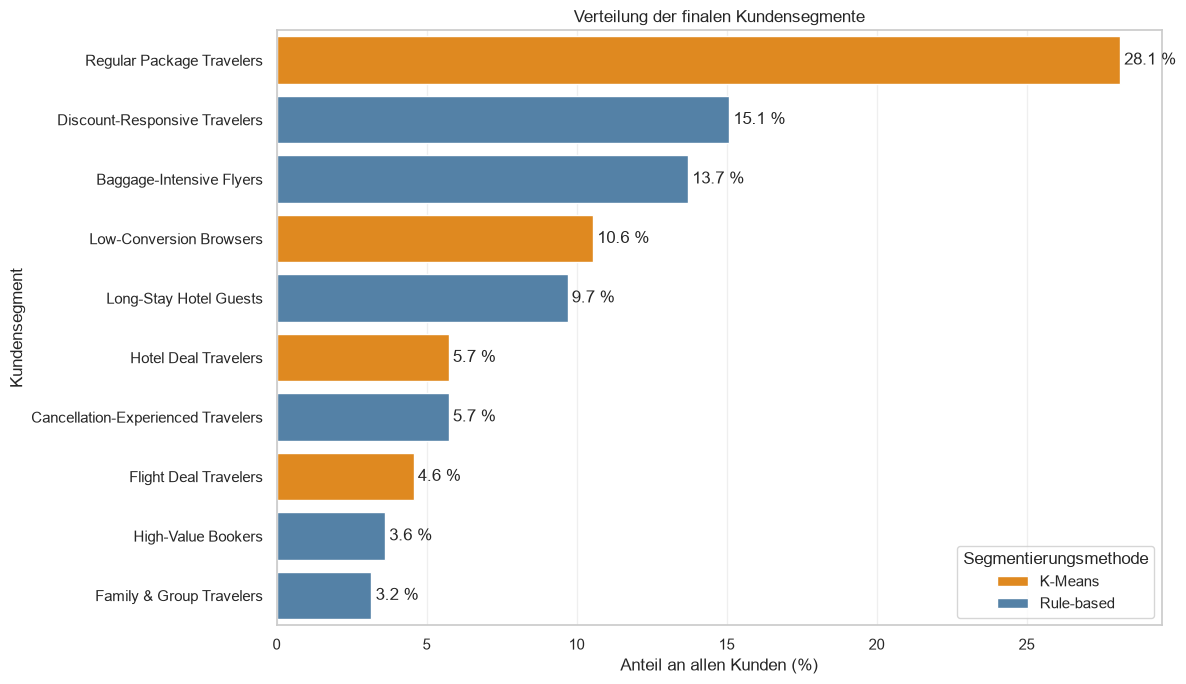

In [6]:
# Segmentgrößen visualisieren.
 
plt.figure(figsize=(12, 7))

segment_plot = sns.barplot(
    data=segment_overview,
    y="final_segment",
    x="customer_share_percent",
    hue="segmentation_method",
    dodge=False,
    palette={
        "Rule-based": "steelblue",
        "K-Means": "darkorange"
    }
)


for container in segment_plot.containers:
    segment_plot.bar_label(
        container,
        fmt="%.1f %%",
        padding=3
    )


plt.title("Verteilung der finalen Kundensegmente")
plt.xlabel("Anteil an allen Kunden (%)")
plt.ylabel("Kundensegment")
plt.legend(title="Segmentierungsmethode")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Vollständigkeit der Segmentübersicht prüfen.

print(
    "Kunden in der Segmentübersicht:",
    segment_overview["customer_count"].sum()
)

print(
    "Summe der Segmentanteile:",
    round(
        segment_overview["customer_share"].sum(),
        3
    )
)

Kunden in der Segmentübersicht: 5752
Summe der Segmentanteile: 1.0


## 3. Perk-Katalog und Bewertungslogik

Bevor den Kundensegmenten konkrete Rewards-Benefits zugeordnet werden, wird
ein einheitlicher Perk-Katalog definiert.

Die ursprüngliche Aufgabenstellung nennt fünf mögliche Vorteile:

- eine kostenlose Hotelmahlzeit,
- kostenloses Aufgabegepäck,
- keine Stornierungsgebühren,
- exklusive Rabatte,
- eine kostenlose Hotelnacht bei gemeinsamer Flug- und Hotelbuchung.

Da die finale Segmentierung zusätzliche Verhaltensmuster wie besonders
wertvolle Kunden, Familien und Kunden mit geringer Buchungsaktivität
identifiziert hat, werden ergänzend drei eigene Benefit-Ideen betrachtet:

- ein Loyalty-Punkte-Multiplikator,
- ein Familien-Reiseguthaben,
- ein einmaliger Buchungsanreiz.

Die zusätzlichen Vorschläge ermöglichen eine bessere Anpassung an die
beobachteten Kundenbedürfnisse. Sie sollten ebenso wie die ursprünglich
vorgesehenen Benefits zunächst in Pilotkampagnen getestet werden.

In [8]:
# Perk-Katalog erstellen.

perk_catalog = pd.DataFrame([
    {
        "perk_id": "hotel_meal",
        "perk_name": "Complimentary Hotel Meal",
        "perk_source": "Original",
        "target_need": "Zusätzlicher Mehrwert während eines Hotelaufenthalts",
        "supporting_behavior": (
            "Regelmäßige oder längere Hotelaufenthalte"
        ),
        "implementation_note": (
            "Wert und Einlösungsbedingungen müssen mit Hotelpartnern "
            "abgestimmt werden."
        )
    },
    {
        "perk_id": "free_checked_bag",
        "perk_name": "Free Checked Bag",
        "perk_source": "Original",
        "target_need": "Reduzierung flugbezogener Zusatzkosten",
        "supporting_behavior": (
            "Regelmäßige Flugreisen mit vergleichsweise viel Aufgabegepäck"
        ),
        "implementation_note": (
            "Der Datensatz enthält keine separaten Gepäckgebühren. "
            "Der Nutzen muss deshalb als Hypothese getestet werden."
        )
    },
    {
        "perk_id": "free_cancellation",
        "perk_name": "No Cancellation Fees",
        "perk_source": "Original",
        "target_need": "Mehr Flexibilität und geringeres Buchungsrisiko",
        "supporting_behavior": (
            "Bisherige Flug- oder Hotelstornierungen"
        ),
        "implementation_note": (
            "Begrenzung auf eine bestimmte Anzahl von Stornierungen "
            "oder einen maximalen Erstattungswert empfohlen."
        )
    },
    {
        "perk_id": "exclusive_discount",
        "perk_name": "Exclusive Travel Discount",
        "perk_source": "Original",
        "target_need": "Preisvorteil und zusätzlicher Buchungsanreiz",
        "supporting_behavior": (
            "Nachweisbare Reaktion auf Flug- oder Hotelrabatte"
        ),
        "implementation_note": (
            "Der Rabatt kann abhängig vom Segment auf Flug-, Hotel- "
            "oder Paketbuchungen ausgerichtet werden."
        )
    },
    {
        "perk_id": "free_hotel_night",
        "perk_name": "Free Hotel Night with Package Booking",
        "perk_source": "Original",
        "target_need": "Belohnung kombinierter Flug- und Hotelbuchungen",
        "supporting_behavior": (
            "Häufige Paketbuchungen oder längere Hotelaufenthalte"
        ),
        "implementation_note": (
            "Mindestaufenthalt oder Mindestbuchungswert kann die Kosten "
            "begrenzen."
        )
    },
    {
        "perk_id": "loyalty_multiplier",
        "perk_name": "Loyalty Points Multiplier",
        "perk_source": "Custom",
        "target_need": "Anerkennung und Bindung besonders wertvoller Kunden",
        "supporting_behavior": (
            "Hoher historischer Kundenwert und regelmäßige Buchungen"
        ),
        "implementation_note": (
            "Beispielsweise doppelte Punkte für einen begrenzten Zeitraum."
        )
    },
    {
        "perk_id": "family_travel_credit",
        "perk_name": "Family Travel Credit",
        "perk_source": "Custom",
        "target_need": "Reduzierung zusätzlicher Kosten bei Familienreisen",
        "supporting_behavior": (
            "Reisen mit Kindern oder mehreren gemeinsam gebuchten Sitzplätzen"
        ),
        "implementation_note": (
            "Beispielsweise Guthaben für Familienzimmer, Kindermenüs "
            "oder Sitzplatzreservierungen."
        )
    },
    {
        "perk_id": "first_booking_incentive",
        "perk_name": "First Booking Incentive",
        "perk_source": "Custom",
        "target_need": "Abbau der Hürde zwischen Suche und erster Buchung",
        "supporting_behavior": (
            "Viele Sessions, aber wenige oder keine abgeschlossenen Buchungen"
        ),
        "implementation_note": (
            "Einmaliger, zeitlich begrenzter Vorteil mit Mindestbuchungswert."
        )
    }
])

display(perk_catalog)

,perk_id,perk_name,perk_source,target_need,supporting_behavior,implementation_note
0,hotel_meal,Complimentary Hotel Meal,Original,Zusätzlicher Mehrwert während eines Hotelaufen...,Regelmäßige oder längere Hotelaufenthalte,Wert und Einlösungsbedingungen müssen mit Hote...
1,free_checked_bag,Free Checked Bag,Original,Reduzierung flugbezogener Zusatzkosten,Regelmäßige Flugreisen mit vergleichsweise vie...,Der Datensatz enthält keine separaten Gepäckge...
2,free_cancellation,No Cancellation Fees,Original,Mehr Flexibilität und geringeres Buchungsrisiko,Bisherige Flug- oder Hotelstornierungen,Begrenzung auf eine bestimmte Anzahl von Storn...
3,exclusive_discount,Exclusive Travel Discount,Original,Preisvorteil und zusätzlicher Buchungsanreiz,Nachweisbare Reaktion auf Flug- oder Hotelrabatte,Der Rabatt kann abhängig vom Segment auf Flug-...
4,free_hotel_night,Free Hotel Night with Package Booking,Original,Belohnung kombinierter Flug- und Hotelbuchungen,Häufige Paketbuchungen oder längere Hotelaufen...,Mindestaufenthalt oder Mindestbuchungswert kan...
5,loyalty_multiplier,Loyalty Points Multiplier,Custom,Anerkennung und Bindung besonders wertvoller K...,Hoher historischer Kundenwert und regelmäßige ...,Beispielsweise doppelte Punkte für einen begre...
6,family_travel_credit,Family Travel Credit,Custom,Reduzierung zusätzlicher Kosten bei Familienre...,Reisen mit Kindern oder mehreren gemeinsam geb...,"Beispielsweise Guthaben für Familienzimmer, Ki..."
7,first_booking_incentive,First Booking Incentive,Custom,Abbau der Hürde zwischen Suche und erster Buchung,"Viele Sessions, aber wenige oder keine abgesch...","Einmaliger, zeitlich begrenzter Vorteil mit Mi..."


### Bewertungsprinzipien für die Perk-Zuweisung

Die Auswahl eines Benefits erfolgt nicht ausschließlich anhand des
Segmentnamens. Für jedes Segment werden mehrere Kriterien berücksichtigt:

1. **Verhaltensbasierte Passung**  
   Der Benefit sollte zu einem tatsächlich beobachteten Buchungs- oder
   Reiseverhalten passen.

2. **Stärke der Datengrundlage**  
   Direkt beobachtete Merkmale wie Stornierungen, Paketbuchungen oder
   Rabattnutzung liefern eine stärkere Grundlage als nicht im Datensatz
   enthaltene Informationen.

3. **Zusätzlicher Kundennutzen**  
   Der Benefit sollte ein relevantes Bedürfnis adressieren oder eine
   erkennbare Buchungshürde reduzieren.

4. **Wirtschaftliche Kontrollierbarkeit**  
   Kostenintensive Vorteile sollten durch Mindestbuchungswerte,
   Einlösegrenzen oder zeitliche Einschränkungen steuerbar sein.

5. **Kommunikative Verständlichkeit**  
   Der Vorteil sollte in einer Kampagne einfach und unmittelbar erklärt
   werden können.

6. **Messbarkeit**  
   Die Wirkung sollte anhand von Kennzahlen wie Buchungsrate,
   Wiederbuchungsrate, Kundenwert oder Einlösungsquote überprüft werden
   können.

Die Zuordnung beschreibt eine datenbasierte Empfehlung, jedoch keine
nachgewiesene individuelle Präferenz. Deshalb sollten die Benefits zunächst
mittels A/B-Tests oder kontrollierter Pilotkampagnen validiert werden.

### Einschränkungen der Datengrundlage

Nicht für jeden möglichen Benefit enthält der Datensatz direkte
Kosten- oder Präferenzinformationen.

Insbesondere ist nicht ersichtlich, ob Kunden in der Vergangenheit separate
Gebühren für Aufgabegepäck oder Hotelmahlzeiten gezahlt haben. Ein hoher
Gepäckanteil zeigt daher lediglich, dass ein Gepäck-Benefit zum bisherigen
Reiseverhalten passen könnte. Er beweist nicht, dass dieser Vorteil für den
Kunden bereits einen finanziellen Mehrwert dargestellt hätte.

Auch eine hohe Nutzung bisheriger Rabatte beweist nicht, dass ein Rabatt
ursächlich für die Buchung war. Die Perk-Zuweisung wird deshalb als
begründete Marketinghypothese verstanden, deren Wirkung nach der Einführung
gemessen werden muss.

## 4. Segmentbedürfnisse und Perk-Kandidaten

Für jedes Kundensegment wird zunächst das charakteristische Verhalten
zusammengefasst und daraus ein wahrscheinliches Kundenbedürfnis abgeleitet.

Die Bedürfnisse sind keine direkt beobachteten Aussagen der Kunden, sondern
datenbasierte Interpretationen des bisherigen Reise- und Buchungsverhaltens.
Sie dienen als Verbindung zwischen der Kundensegmentierung und der späteren
Perk-Empfehlung.

In diesem Schritt werden zunächst mehrere geeignete Benefits je Segment
betrachtet. Die endgültige Auswahl eines primären Perks erfolgt anschließend
anhand der Verhaltenspassung, der Stärke der Datengrundlage und der
wirtschaftlichen Umsetzbarkeit.

In [9]:
# Relevante Segmentmerkmale zusammenfassen.

segment_profile_candidates = [
    "session_count",
    "booking_session_count",
    "booking_session_rate",
    "package_booking_rate",
    "flight_booking_count",
    "hotel_booking_count",
    "mean_seats",
    "checked_bags_per_seat",
    "mean_hotel_nights",
    "extended_stay_booking_share",
    "flight_discount_conversion_rate",
    "hotel_discount_conversion_rate",
    "total_cancelled_bookings",
    "historical_customer_value_usd",
    "has_children"
]


available_segment_profile_columns = [
    column
    for column in segment_profile_candidates
    if column in customers.columns
]


print("Verwendete Profilmerkmale:")
print(available_segment_profile_columns)

Verwendete Profilmerkmale:
['session_count', 'booking_session_count', 'booking_session_rate', 'package_booking_rate', 'flight_booking_count', 'hotel_booking_count', 'mean_seats', 'checked_bags_per_seat', 'mean_hotel_nights', 'extended_stay_booking_share', 'flight_discount_conversion_rate', 'hotel_discount_conversion_rate', 'total_cancelled_bookings', 'historical_customer_value_usd', 'has_children']


In [10]:
# Mittelwerte je Segment.

segment_profile_means = (
    customers
    .groupby("final_segment")[
        available_segment_profile_columns
    ]
    .mean()
    .round(2)
)

display(segment_profile_means)

,session_count,booking_session_count,booking_session_rate,package_booking_rate,flight_booking_count,hotel_booking_count,mean_seats,checked_bags_per_seat,mean_hotel_nights,extended_stay_booking_share,flight_discount_conversion_rate,hotel_discount_conversion_rate,total_cancelled_bookings,historical_customer_value_usd,has_children
final_segment,,,,,,,,,,,,,,,
Baggage-Intensive Flyers,8.200,3.450,0.420,0.800,3.090,3.070,1.080,0.970,3.070,0.050,0.310,0.370,0.140,3045.040,0.320
Cancellation-Experienced Travelers,8.310,3.170,0.380,0.680,2.850,2.620,1.250,0.390,3.200,0.050,0.120,0.120,1.650,1959.540,0.270
Discount-Responsive Travelers,8.210,3.700,0.450,0.810,3.320,3.380,1.200,0.370,3.180,0.050,0.590,0.680,0.060,3670.540,0.260
Family & Group Travelers,8.160,2.470,0.300,0.620,2.030,1.990,2.520,0.500,4.790,0.050,0.220,0.220,0.460,4016.380,1.000
Flight Deal Travelers,8.160,3.140,0.380,0.790,2.890,2.740,1.160,0.400,2.880,0.050,0.750,0.020,0.000,2605.700,0.310
High-Value Bookers,8.210,4.290,0.520,0.750,3.570,4.000,1.360,0.390,4.200,0.060,0.210,0.340,0.000,7875.730,0.260
Hotel Deal Travelers,8.210,3.000,0.370,0.760,2.500,2.780,1.140,0.380,3.200,0.060,0.050,0.730,0.000,2607.050,0.300
Long-Stay Hotel Guests,8.210,2.210,0.270,0.420,1.290,1.940,1.180,0.370,9.850,0.040,0.130,0.260,0.250,4208.420,0.290
Low-Conversion Browsers,8.190,0.540,0.070,0.140,0.160,0.480,1.000,0.000,4.130,0.010,0.000,0.020,0.000,476.420,0.370


In [11]:
# Mediane je Segment.

segment_profile_medians = (
    customers
    .groupby("final_segment")[
        available_segment_profile_columns
    ]
    .median()
    .round(2)
)

display(segment_profile_medians)

,session_count,booking_session_count,booking_session_rate,package_booking_rate,flight_booking_count,hotel_booking_count,mean_seats,checked_bags_per_seat,mean_hotel_nights,extended_stay_booking_share,flight_discount_conversion_rate,hotel_discount_conversion_rate,total_cancelled_bookings,historical_customer_value_usd,has_children
final_segment,,,,,,,,,,,,,,,
Baggage-Intensive Flyers,8.000,3.000,0.380,0.800,3.000,3.000,1.000,1.000,2.830,0.000,0.000,0.330,0.000,2649.850,0.000
Cancellation-Experienced Travelers,8.000,3.000,0.380,0.750,3.000,3.000,1.000,0.430,3.000,0.000,0.000,0.000,2.000,1674.890,0.000
Discount-Responsive Travelers,8.000,4.000,0.440,0.830,3.000,3.000,1.000,0.330,3.000,0.000,0.500,0.670,0.000,3238.760,0.000
Family & Group Travelers,8.000,2.000,0.250,0.670,2.000,2.000,2.000,0.500,4.000,0.000,0.000,0.000,0.000,3312.460,1.000
Flight Deal Travelers,8.000,3.000,0.380,1.000,3.000,3.000,1.000,0.330,2.500,0.000,0.670,0.000,0.000,2445.700,0.000
High-Value Bookers,8.000,4.000,0.500,0.800,4.000,4.000,1.330,0.400,4.210,0.000,0.000,0.000,0.000,7210.020,0.000
Hotel Deal Travelers,8.000,3.000,0.380,0.750,2.000,3.000,1.000,0.330,3.000,0.000,0.000,0.500,0.000,2387.360,0.000
Long-Stay Hotel Guests,8.000,2.000,0.250,0.500,1.000,2.000,1.000,0.000,9.000,0.000,0.000,0.000,0.000,3269.130,0.000
Low-Conversion Browsers,8.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,4.000,0.000,0.000,0.000,0.000,0.000,0.000


In [12]:
# Bedürfnis- und Evidenztabelle erstellen.

segment_needs = pd.DataFrame([
    {
        "final_segment": "Family & Group Travelers",
        "characteristic_behavior": (
            "Reisen mit Kindern und mehreren gemeinsam gebuchten Sitzplätzen"
        ),
        "inferred_need": (
            "Reduzierung zusätzlicher Kosten und organisatorischer "
            "Belastungen bei gemeinsamen Reisen"
        ),
        "primary_evidence": (
            "Kinder im Haushalt und überdurchschnittliche Sitzplatzanzahl"
        ),
        "candidate_perks": (
            "Family Travel Credit; Complimentary Hotel Meal"
        )
    },
    {
        "final_segment": "Long-Stay Hotel Guests",
        "characteristic_behavior": (
            "Überdurchschnittlich lange Hotelaufenthalte"
        ),
        "inferred_need": (
            "Zusätzlicher Gegenwert bei längeren und potenziell "
            "kostenintensiven Aufenthalten"
        ),
        "primary_evidence": (
            "Durchschnittlich mindestens sieben Hotelnächte"
        ),
        "candidate_perks": (
            "Free Hotel Night with Package Booking; "
            "Complimentary Hotel Meal"
        )
    },
    {
        "final_segment": "Baggage-Intensive Flyers",
        "characteristic_behavior": (
            "Regelmäßige Flugbuchungen mit vergleichsweise viel "
            "Aufgabegepäck je Sitzplatz"
        ),
        "inferred_need": (
            "Einfachere Gepäckmitnahme und mögliche Reduzierung "
            "flugbezogener Zusatzkosten"
        ),
        "primary_evidence": (
            "Mindestens zwei Flugbuchungen und hoher Gepäckanteil je Sitzplatz"
        ),
        "candidate_perks": (
            "Free Checked Bag; Exclusive Travel Discount"
        )
    },
    {
        "final_segment": "Discount-Responsive Travelers",
        "characteristic_behavior": (
            "Wiederholte Nutzung angebotener Flug- oder Hotelrabatte"
        ),
        "inferred_need": (
            "Sichtbarer Preisvorteil als zusätzlicher Buchungsanreiz"
        ),
        "primary_evidence": (
            "Mindestens zwei Angebote und hohe Rabatt-Konversionsrate"
        ),
        "candidate_perks": (
            "Exclusive Travel Discount; Loyalty Points Multiplier"
        )
    },
    {
        "final_segment": "Cancellation-Experienced Travelers",
        "characteristic_behavior": (
            "Mindestens eine bisherige Flug- oder Hotelstornierung"
        ),
        "inferred_need": (
            "Mehr Flexibilität und geringeres finanzielles Buchungsrisiko"
        ),
        "primary_evidence": (
            "Historisch beobachtete Stornierungen"
        ),
        "candidate_perks": (
            "No Cancellation Fees; Exclusive Travel Discount"
        )
    },
    {
        "final_segment": "High-Value Bookers",
        "characteristic_behavior": (
            "Besonders hoher bisheriger Kundenwert"
        ),
        "inferred_need": (
            "Anerkennung, Exklusivität und langfristige Belohnung "
            "der Kundenbeziehung"
        ),
        "primary_evidence": (
            "Historischer Kundenwert in den obersten zehn Prozent"
        ),
        "candidate_perks": (
            "Loyalty Points Multiplier; Exclusive Travel Discount"
        )
    },
    {
        "final_segment": "Flight Deal Travelers",
        "characteristic_behavior": (
            "Hohe Nutzung von Flugrabatten und regelmäßige Flugbuchungen"
        ),
        "inferred_need": (
            "Preisvorteil bei zukünftigen Flug- oder Paketbuchungen"
        ),
        "primary_evidence": (
            "Hohe Flugrabatt-Konversionsrate und überdurchschnittliche "
            "Flugaktivität"
        ),
        "candidate_perks": (
            "Flight-focused Exclusive Travel Discount; Free Checked Bag"
        )
    },
    {
        "final_segment": "Hotel Deal Travelers",
        "characteristic_behavior": (
            "Hohe Nutzung von Hotelrabatten und regelmäßige Hotelbuchungen"
        ),
        "inferred_need": (
            "Preisvorteil oder zusätzlicher Mehrwert bei Hotelaufenthalten"
        ),
        "primary_evidence": (
            "Hohe Hotelrabatt-Konversionsrate und überdurchschnittliche "
            "Hotelaktivität"
        ),
        "candidate_perks": (
            "Hotel-focused Exclusive Travel Discount; "
            "Complimentary Hotel Meal"
        )
    },
    {
        "final_segment": "Low-Conversion Browsers",
        "characteristic_behavior": (
            "Ähnliche Sessionanzahl wie andere Kunden, aber sehr wenige "
            "abgeschlossene Buchungen"
        ),
        "inferred_need": (
            "Niedrigere Einstiegshürde und klarer Anreiz für eine "
            "erste beziehungsweise erneute Buchung"
        ),
        "primary_evidence": (
            "Sehr niedrige Buchungssessionsrate und niedriger historischer "
            "Kundenwert"
        ),
        "candidate_perks": (
            "First Booking Incentive; Exclusive Travel Discount"
        )
    },
    {
        "final_segment": "Regular Package Travelers",
        "characteristic_behavior": (
            "Regelmäßige kombinierte Flug- und Hotelbuchungen ohne "
            "ausgeprägte Rabattnutzung"
        ),
        "inferred_need": (
            "Belohnung des bestehenden Paketbuchungsverhaltens und "
            "Anreiz zur Wiederbuchung"
        ),
        "primary_evidence": (
            "Hohe Paketbuchungsrate und regelmäßige Flug- und Hotelaktivität"
        ),
        "candidate_perks": (
            "Free Hotel Night with Package Booking; "
            "Loyalty Points Multiplier"
        )
    }
])

display(segment_needs)

,final_segment,characteristic_behavior,inferred_need,primary_evidence,candidate_perks
0,Family & Group Travelers,Reisen mit Kindern und mehreren gemeinsam gebu...,Reduzierung zusätzlicher Kosten und organisato...,Kinder im Haushalt und überdurchschnittliche S...,Family Travel Credit; Complimentary Hotel Meal
1,Long-Stay Hotel Guests,Überdurchschnittlich lange Hotelaufenthalte,Zusätzlicher Gegenwert bei längeren und potenz...,Durchschnittlich mindestens sieben Hotelnächte,Free Hotel Night with Package Booking; Complim...
2,Baggage-Intensive Flyers,Regelmäßige Flugbuchungen mit vergleichsweise ...,Einfachere Gepäckmitnahme und mögliche Reduzie...,Mindestens zwei Flugbuchungen und hoher Gepäck...,Free Checked Bag; Exclusive Travel Discount
3,Discount-Responsive Travelers,Wiederholte Nutzung angebotener Flug- oder Hot...,Sichtbarer Preisvorteil als zusätzlicher Buchu...,Mindestens zwei Angebote und hohe Rabatt-Konve...,Exclusive Travel Discount; Loyalty Points Mult...
4,Cancellation-Experienced Travelers,Mindestens eine bisherige Flug- oder Hotelstor...,Mehr Flexibilität und geringeres finanzielles ...,Historisch beobachtete Stornierungen,No Cancellation Fees; Exclusive Travel Discount
5,High-Value Bookers,Besonders hoher bisheriger Kundenwert,"Anerkennung, Exklusivität und langfristige Bel...",Historischer Kundenwert in den obersten zehn P...,Loyalty Points Multiplier; Exclusive Travel Di...
6,Flight Deal Travelers,Hohe Nutzung von Flugrabatten und regelmäßige ...,Preisvorteil bei zukünftigen Flug- oder Paketb...,Hohe Flugrabatt-Konversionsrate und überdurchs...,Flight-focused Exclusive Travel Discount; Free...
7,Hotel Deal Travelers,Hohe Nutzung von Hotelrabatten und regelmäßige...,Preisvorteil oder zusätzlicher Mehrwert bei Ho...,Hohe Hotelrabatt-Konversionsrate und überdurch...,Hotel-focused Exclusive Travel Discount; Compl...
8,Low-Conversion Browsers,"Ähnliche Sessionanzahl wie andere Kunden, aber...",Niedrigere Einstiegshürde und klarer Anreiz fü...,Sehr niedrige Buchungssessionsrate und niedrig...,First Booking Incentive; Exclusive Travel Disc...
9,Regular Package Travelers,Regelmäßige kombinierte Flug- und Hotelbuchung...,Belohnung des bestehenden Paketbuchungsverhalt...,Hohe Paketbuchungsrate und regelmäßige Flug- u...,Free Hotel Night with Package Booking; Loyalty...


In [13]:
# Vollständigkeit kontrollieren.

segments_in_customer_data = set(
    customers["final_segment"].unique()
)

segments_in_needs_table = set(
    segment_needs["final_segment"]
)


print(
    "Segmente in den Kundendaten:",
    len(segments_in_customer_data)
)

print(
    "Segmente in der Bedürfnistabelle:",
    len(segments_in_needs_table)
)

print(
    "Fehlende Segmente:",
    segments_in_customer_data
    - segments_in_needs_table
)

print(
    "Unbekannte zusätzliche Segmente:",
    segments_in_needs_table
    - segments_in_customer_data
)

Segmente in den Kundendaten: 10
Segmente in der Bedürfnistabelle: 10
Fehlende Segmente: set()
Unbekannte zusätzliche Segmente: set()


In [14]:
# Kompakte Übersicht erzeugen.
 
segment_strategy_overview = (
    segment_overview[
        [
            "final_segment",
            "customer_count",
            "customer_share_percent"
        ]
    ]
    .merge(
        segment_needs,
        on="final_segment",
        how="left",
        validate="one_to_one"
    )
)

display(segment_strategy_overview)

,final_segment,customer_count,customer_share_percent,characteristic_behavior,inferred_need,primary_evidence,candidate_perks
0,Regular Package Travelers,1617,28.112,Regelmäßige kombinierte Flug- und Hotelbuchung...,Belohnung des bestehenden Paketbuchungsverhalt...,Hohe Paketbuchungsrate und regelmäßige Flug- u...,Free Hotel Night with Package Booking; Loyalty...
1,Discount-Responsive Travelers,868,15.090,Wiederholte Nutzung angebotener Flug- oder Hot...,Sichtbarer Preisvorteil als zusätzlicher Buchu...,Mindestens zwei Angebote und hohe Rabatt-Konve...,Exclusive Travel Discount; Loyalty Points Mult...
2,Baggage-Intensive Flyers,789,13.717,Regelmäßige Flugbuchungen mit vergleichsweise ...,Einfachere Gepäckmitnahme und mögliche Reduzie...,Mindestens zwei Flugbuchungen und hoher Gepäck...,Free Checked Bag; Exclusive Travel Discount
3,Low-Conversion Browsers,607,10.553,"Ähnliche Sessionanzahl wie andere Kunden, aber...",Niedrigere Einstiegshürde und klarer Anreiz fü...,Sehr niedrige Buchungssessionsrate und niedrig...,First Booking Incentive; Exclusive Travel Disc...
4,Long-Stay Hotel Guests,558,9.701,Überdurchschnittlich lange Hotelaufenthalte,Zusätzlicher Gegenwert bei längeren und potenz...,Durchschnittlich mindestens sieben Hotelnächte,Free Hotel Night with Package Booking; Complim...
5,Hotel Deal Travelers,330,5.737,Hohe Nutzung von Hotelrabatten und regelmäßige...,Preisvorteil oder zusätzlicher Mehrwert bei Ho...,Hohe Hotelrabatt-Konversionsrate und überdurch...,Hotel-focused Exclusive Travel Discount; Compl...
6,Cancellation-Experienced Travelers,330,5.737,Mindestens eine bisherige Flug- oder Hotelstor...,Mehr Flexibilität und geringeres finanzielles ...,Historisch beobachtete Stornierungen,No Cancellation Fees; Exclusive Travel Discount
7,Flight Deal Travelers,263,4.572,Hohe Nutzung von Flugrabatten und regelmäßige ...,Preisvorteil bei zukünftigen Flug- oder Paketb...,Hohe Flugrabatt-Konversionsrate und überdurchs...,Flight-focused Exclusive Travel Discount; Free...
8,High-Value Bookers,208,3.616,Besonders hoher bisheriger Kundenwert,"Anerkennung, Exklusivität und langfristige Bel...",Historischer Kundenwert in den obersten zehn P...,Loyalty Points Multiplier; Exclusive Travel Di...
9,Family & Group Travelers,182,3.164,Reisen mit Kindern und mehreren gemeinsam gebu...,Reduzierung zusätzlicher Kosten und organisato...,Kinder im Haushalt und überdurchschnittliche S...,Family Travel Credit; Complimentary Hotel Meal


## 5. Primäre Perk-Zuweisung

Auf Grundlage der zuvor abgeleiteten Segmentbedürfnisse wird jedem Kundensegment ein primärer Perk zugeordnet. Die Zuweisung orientiert sich am charakteristischen Verhalten des Segments und daran, welcher Vorteil voraussichtlich den größten zusätzlichen Nutzen bietet.

Mehrere Segmente können ein ähnliches Grundbedürfnis aufweisen und daher demselben Perk-Typ zugeordnet werden. Die konkrete Ausgestaltung, Ansprache und Erfolgsmessung erfolgt dennoch segmentspezifisch. Dadurch bleibt das Rewards-Programm operativ handhabbar, ohne auf eine personalisierte Kundenansprache zu verzichten. Die Zuordnung stellt also eine datenbasierte Hypothese dar und sollte später durch kontrollierte Kampagnentests überprüft werden.

In [15]:
# Zuordnungslogik festlegen.

perk_assignment = pd.DataFrame([
    {
        "final_segment": "Family & Group Travelers",
        "primary_perk_id": "family_travel_credit",
        "primary_perk": "Family Travel Credit",
        "alternative_test_perk": "Complimentary Hotel Meal",
        "recommendation_reason": (
            "Das Segment reist häufiger mit mehreren Personen und Kindern. "
            "Ein Familien-Reiseguthaben reduziert unmittelbar die Kosten "
            "größerer Buchungen."
        ),
        "success_kpi": "Buchungsrate von Familien- und Gruppenreisen",
        "guardrail": "Durchschnittliche Perk-Kosten pro Buchung"
    },
    {
        "final_segment": "Long-Stay Hotel Guests",
        "primary_perk_id": "hotel_meal",
        "primary_perk": "Complimentary Hotel Meal",
        "alternative_test_perk": "Free Hotel Night",
        "recommendation_reason": (
            "Bei längeren Hotelaufenthalten entsteht ein wiederkehrender "
            "Bedarf an Verpflegung. Eine kostenlose Mahlzeit bietet einen "
            "direkten Nutzen bei kontrollierbaren Kosten."
        ),
        "success_kpi": "Erneute Hotelbuchungsrate und gebuchte Übernachtungen",
        "guardrail": "Kosten der Mahlzeit pro zusätzlicher Buchung"
    },
    {
        "final_segment": "Baggage-Intensive Flyers",
        "primary_perk_id": "free_checked_bag",
        "primary_perk": "Free Checked Bag",
        "alternative_test_perk": "Exclusive Flight Discount",
        "recommendation_reason": (
            "Das Segment nutzt im Verhältnis zu den gebuchten Sitzplätzen "
            "besonders häufig Aufgabegepäck. Der Vorteil passt deshalb "
            "unmittelbar zum beobachteten Reiseverhalten."
        ),
        "success_kpi": "Erneute Flugbuchungsrate",
        "guardrail": "Gepäckkosten pro zusätzlicher Flugbuchung"
    },
    {
        "final_segment": "Discount-Responsive Travelers",
        "primary_perk_id": "exclusive_discount",
        "primary_perk": "Exclusive Travel Discount",
        "alternative_test_perk": "Loyalty Points Multiplier",
        "recommendation_reason": (
            "Diese Kunden haben angebotene Rabatte bereits überdurchschnittlich "
            "häufig genutzt und reagieren daher wahrscheinlich auch künftig "
            "auf preisbezogene Anreize."
        ),
        "success_kpi": "Inkrementelle Buchungsrate nach Rabattangebot",
        "guardrail": "Deckungsbeitrag nach Rabatt"
    },
    {
        "final_segment": "Cancellation-Experienced Travelers",
        "primary_perk_id": "free_cancellation",
        "primary_perk": "No Cancellation Fees",
        "alternative_test_perk": "Exclusive Travel Discount",
        "recommendation_reason": (
            "Das Segment weist bereits stornierte Buchungen auf. Eine "
            "kostenfreie Stornierungsoption reduziert das wahrgenommene "
            "Buchungsrisiko und kann erneute Buchungen erleichtern."
        ),
        "success_kpi": "Erneute Buchungsrate",
        "guardrail": "Stornierungsquote und entgangene Gebühren"
    },
    {
        "final_segment": "High-Value Bookers",
        "primary_perk_id": "loyalty_multiplier",
        "primary_perk": "Loyalty Points Multiplier",
        "alternative_test_perk": "Free Hotel Night with Package Booking",
        "recommendation_reason": (
            "Diese Kunden besitzen bereits einen hohen historischen Wert. "
            "Ein Punkte-Multiplikator belohnt ihre Loyalität, ohne jede "
            "Buchung unmittelbar zu rabattieren."
        ),
        "success_kpi": "Wiederbuchungsrate und Entwicklung des Kundenwerts",
        "guardrail": "Kosten der vergebenen Zusatzpunkte"
    },
    {
        "final_segment": "Flight Deal Travelers",
        "primary_perk_id": "exclusive_discount",
        "primary_perk": "Exclusive Flight Discount",
        "alternative_test_perk": "Free Checked Bag",
        "recommendation_reason": (
            "Das Segment reagiert vor allem bei Flugangeboten auf Rabatte. "
            "Daher wird der allgemeine Rabatt-Perk als gezielter Flugrabatt "
            "kommuniziert."
        ),
        "success_kpi": "Flugbuchungsrate nach Rabattangebot",
        "guardrail": "Deckungsbeitrag der rabattierten Flüge"
    },
    {
        "final_segment": "Hotel Deal Travelers",
        "primary_perk_id": "exclusive_discount",
        "primary_perk": "Exclusive Hotel Discount",
        "alternative_test_perk": "Complimentary Hotel Meal",
        "recommendation_reason": (
            "Das Segment reagiert insbesondere auf Hotelangebote. Ein gezielter "
            "Hotelrabatt entspricht daher besser seinem Verhalten als ein "
            "allgemein formulierter Reisevorteil."
        ),
        "success_kpi": "Hotelbuchungsrate nach Rabattangebot",
        "guardrail": "Deckungsbeitrag der rabattierten Hotels"
    },
    {
        "final_segment": "Low-Conversion Browsers",
        "primary_perk_id": "first_booking_incentive",
        "primary_perk": "First Booking Incentive",
        "alternative_test_perk": "Exclusive Travel Discount",
        "recommendation_reason": (
            "Diese Kunden zeigen Suchaktivität, führen jedoch vergleichsweise "
            "selten eine Buchung durch. Ein einmaliger Einstiegsanreiz soll "
            "die erste beziehungsweise nächste Buchung fördern."
        ),
        "success_kpi": "Conversion von der Suche zur Buchung",
        "guardrail": "Anreizkosten pro zusätzlicher Buchung"
    },
    {
        "final_segment": "Regular Package Travelers",
        "primary_perk_id": "free_hotel_night",
        "primary_perk": "Free Hotel Night with Package Booking",
        "alternative_test_perk": "Loyalty Points Multiplier",
        "recommendation_reason": (
            "Das Segment bucht regelmäßig kombinierte Flug- und Hotelreisen. "
            "Eine kostenlose Hotelnacht bei einer Paketbuchung passt direkt "
            "zu diesem Verhalten und fördert weitere kombinierte Buchungen."
        ),
        "success_kpi": "Wiederholte Paketbuchungsrate",
        "guardrail": "Kosten der Hotelnacht pro zusätzlicher Paketbuchung"
    }
])

display(perk_assignment)

,final_segment,primary_perk_id,primary_perk,alternative_test_perk,recommendation_reason,success_kpi,guardrail
0,Family & Group Travelers,family_travel_credit,Family Travel Credit,Complimentary Hotel Meal,Das Segment reist häufiger mit mehreren Person...,Buchungsrate von Familien- und Gruppenreisen,Durchschnittliche Perk-Kosten pro Buchung
1,Long-Stay Hotel Guests,hotel_meal,Complimentary Hotel Meal,Free Hotel Night,Bei längeren Hotelaufenthalten entsteht ein wi...,Erneute Hotelbuchungsrate und gebuchte Übernac...,Kosten der Mahlzeit pro zusätzlicher Buchung
2,Baggage-Intensive Flyers,free_checked_bag,Free Checked Bag,Exclusive Flight Discount,Das Segment nutzt im Verhältnis zu den gebucht...,Erneute Flugbuchungsrate,Gepäckkosten pro zusätzlicher Flugbuchung
3,Discount-Responsive Travelers,exclusive_discount,Exclusive Travel Discount,Loyalty Points Multiplier,Diese Kunden haben angebotene Rabatte bereits ...,Inkrementelle Buchungsrate nach Rabattangebot,Deckungsbeitrag nach Rabatt
4,Cancellation-Experienced Travelers,free_cancellation,No Cancellation Fees,Exclusive Travel Discount,Das Segment weist bereits stornierte Buchungen...,Erneute Buchungsrate,Stornierungsquote und entgangene Gebühren
5,High-Value Bookers,loyalty_multiplier,Loyalty Points Multiplier,Free Hotel Night with Package Booking,Diese Kunden besitzen bereits einen hohen hist...,Wiederbuchungsrate und Entwicklung des Kundenw...,Kosten der vergebenen Zusatzpunkte
6,Flight Deal Travelers,exclusive_discount,Exclusive Flight Discount,Free Checked Bag,Das Segment reagiert vor allem bei Flugangebot...,Flugbuchungsrate nach Rabattangebot,Deckungsbeitrag der rabattierten Flüge
7,Hotel Deal Travelers,exclusive_discount,Exclusive Hotel Discount,Complimentary Hotel Meal,Das Segment reagiert insbesondere auf Hotelang...,Hotelbuchungsrate nach Rabattangebot,Deckungsbeitrag der rabattierten Hotels
8,Low-Conversion Browsers,first_booking_incentive,First Booking Incentive,Exclusive Travel Discount,"Diese Kunden zeigen Suchaktivität, führen jedo...",Conversion von der Suche zur Buchung,Anreizkosten pro zusätzlicher Buchung
9,Regular Package Travelers,free_hotel_night,Free Hotel Night with Package Booking,Loyalty Points Multiplier,Das Segment bucht regelmäßig kombinierte Flug-...,Wiederholte Paketbuchungsrate,Kosten der Hotelnacht pro zusätzlicher Paketbu...


In [16]:
# Vollständigkeit und Gültigkeit prüfen.

expected_segments = set(customers["final_segment"].dropna().unique())
assigned_segments = set(perk_assignment["final_segment"])

print(
    "Segmente ohne Perk-Zuweisung:",
    sorted(expected_segments - assigned_segments)
)

print(
    "Zuweisungen ohne vorhandenes Kundensegment:",
    sorted(assigned_segments - expected_segments)
)

print(
    "Doppelte Segmentzuweisungen:",
    perk_assignment["final_segment"].duplicated().sum()
)

Segmente ohne Perk-Zuweisung: []
Zuweisungen ohne vorhandenes Kundensegment: []
Doppelte Segmentzuweisungen: 0


In [17]:
# Prüfung, ob alle Perk-IDs gültig sind.

valid_perk_ids = set(perk_catalog["perk_id"])

invalid_perk_ids = sorted(
    set(perk_assignment["primary_perk_id"]) - valid_perk_ids
)

print("Nicht im Perk-Katalog enthaltene IDs:", invalid_perk_ids)

Nicht im Perk-Katalog enthaltene IDs: []


In [18]:
# Perks den einzelnen Kunden zuweisen

customers_with_perks = customers.merge(
    perk_assignment,
    on="final_segment",
    how="left",
    validate="many_to_one"
)

print("Zeilen:", len(customers_with_perks))
print("Eindeutige Nutzer:", customers_with_perks["user_id"].nunique())
print(
    "Nutzer ohne primären Perk:",
    customers_with_perks["primary_perk"].isna().sum()
)

display(
    customers_with_perks[
        [
            "user_id",
            "final_segment",
            "segmentation_method",
            "primary_perk",
            "alternative_test_perk"
        ]
    ].head()
)

Zeilen: 5752
Eindeutige Nutzer: 5752
Nutzer ohne primären Perk: 0


,user_id,final_segment,segmentation_method,primary_perk,alternative_test_perk
0,23557,Long-Stay Hotel Guests,Rule-based,Complimentary Hotel Meal,Free Hotel Night
1,94883,Regular Package Travelers,K-Means,Free Hotel Night with Package Booking,Loyalty Points Multiplier
2,101486,Low-Conversion Browsers,K-Means,First Booking Incentive,Exclusive Travel Discount
3,101961,Flight Deal Travelers,K-Means,Exclusive Flight Discount,Free Checked Bag
4,106907,Family & Group Travelers,Rule-based,Family Travel Credit,Complimentary Hotel Meal


In [19]:
# Verteilung der Perk-Zuweisungen prüfen

perk_distribution = (
    customers_with_perks
    .groupby(
        ["primary_perk_id", "primary_perk"],
        as_index=False
    )
    .agg(
        customer_count=("user_id", "nunique")
    )
)

perk_distribution["customer_share_pct"] = (
    perk_distribution["customer_count"]
    / customers_with_perks["user_id"].nunique()
    * 100
)

perk_distribution = perk_distribution.sort_values(
    "customer_count",
    ascending=False
).reset_index(drop=True)

display(perk_distribution)

,primary_perk_id,primary_perk,customer_count,customer_share_pct
0,free_hotel_night,Free Hotel Night with Package Booking,1617,28.112
1,exclusive_discount,Exclusive Travel Discount,868,15.090
2,free_checked_bag,Free Checked Bag,789,13.717
3,first_booking_incentive,First Booking Incentive,607,10.553
4,hotel_meal,Complimentary Hotel Meal,558,9.701
5,exclusive_discount,Exclusive Hotel Discount,330,5.737
6,free_cancellation,No Cancellation Fees,330,5.737
7,exclusive_discount,Exclusive Flight Discount,263,4.572
8,loyalty_multiplier,Loyalty Points Multiplier,208,3.616
9,family_travel_credit,Family Travel Credit,182,3.164


## 6. Auswertung der Perk-Zuweisung

Nach der Zuweisung wird untersucht, wie sich die empfohlenen Perks auf die
Kunden verteilen. Da die Zuweisung auf Segmentebene erfolgt, entspricht die
Perk-Verteilung unmittelbar der Größe der jeweils zugeordneten Segmente.

Mehrere Segmente können denselben grundlegenden Perk-Typ erhalten. Die konkrete
Ausgestaltung und Kommunikation kann dennoch segmentspezifisch erfolgen.

In [20]:
# Verteilung nach konkretem Perk-Angebot.

perk_offer_distribution = (
    customers_with_perks
    .groupby("primary_perk", as_index=False)
    .agg(
        customer_count=("user_id", "nunique")
    )
    .sort_values(
        "customer_count",
        ascending=False
    )
    .reset_index(drop=True)
)

perk_offer_distribution["customer_share_pct"] = (
    perk_offer_distribution["customer_count"]
    / customers_with_perks["user_id"].nunique()
    * 100
)

display(perk_offer_distribution)

,primary_perk,customer_count,customer_share_pct
0,Free Hotel Night with Package Booking,1617,28.112
1,Exclusive Travel Discount,868,15.090
2,Free Checked Bag,789,13.717
3,First Booking Incentive,607,10.553
4,Complimentary Hotel Meal,558,9.701
5,No Cancellation Fees,330,5.737
6,Exclusive Hotel Discount,330,5.737
7,Exclusive Flight Discount,263,4.572
8,Loyalty Points Multiplier,208,3.616
9,Family Travel Credit,182,3.164


In [21]:
# Verteilung nach technischem Perk-Typ.

perk_type_distribution = (
    customers_with_perks
    .groupby("primary_perk_id", as_index=False)
    .agg(
        customer_count=("user_id", "nunique"),
        assigned_segments=("final_segment", "nunique")
    )
    .sort_values(
        "customer_count",
        ascending=False
    )
    .reset_index(drop=True)
)

perk_type_distribution["customer_share_pct"] = (
    perk_type_distribution["customer_count"]
    / customers_with_perks["user_id"].nunique()
    * 100
)

display(perk_type_distribution)

,primary_perk_id,customer_count,assigned_segments,customer_share_pct
0,free_hotel_night,1617,1,28.112
1,exclusive_discount,1461,3,25.400
2,free_checked_bag,789,1,13.717
3,first_booking_incentive,607,1,10.553
4,hotel_meal,558,1,9.701
5,free_cancellation,330,1,5.737
6,loyalty_multiplier,208,1,3.616
7,family_travel_credit,182,1,3.164


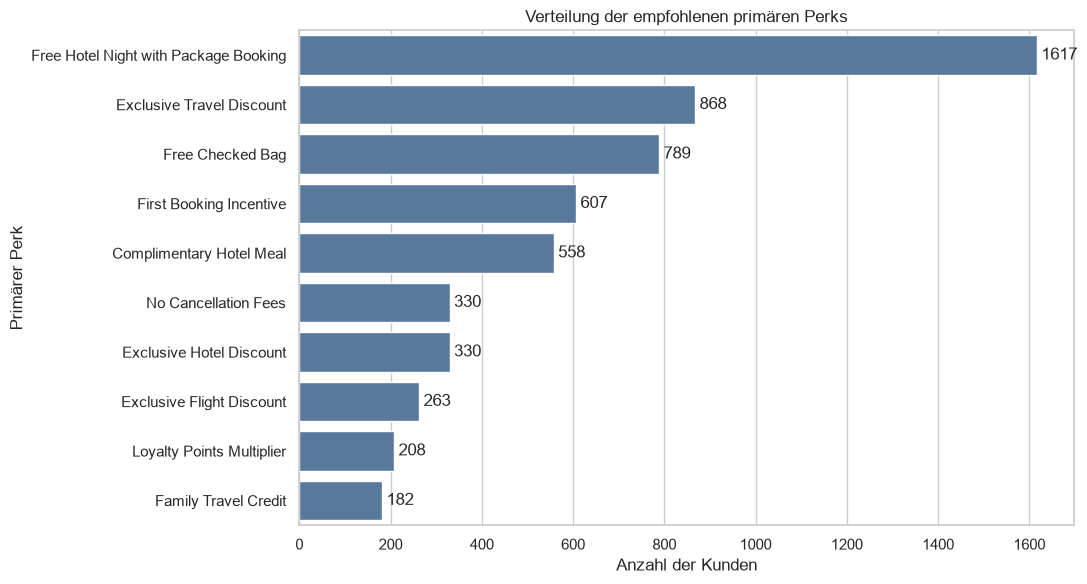

In [22]:
# Verteilung visualisieren.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=perk_offer_distribution,
    x="customer_count",
    y="primary_perk",
    color="#4C78A8"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3
    )

plt.title("Verteilung der empfohlenen primären Perks")
plt.xlabel("Anzahl der Kunden")
plt.ylabel("Primärer Perk")
plt.tight_layout()
plt.show()

In [23]:
# Segment-Perk-Zuordnung als Übersicht.

segment_perk_overview = (
    customers_with_perks
    .groupby(
        [
            "final_segment",
            "primary_perk_id",
            "primary_perk",
            "alternative_test_perk"
        ],
        as_index=False
    )
    .agg(
        customer_count=("user_id", "nunique")
    )
)

segment_perk_overview["segment_share_pct"] = (
    segment_perk_overview["customer_count"]
    / customers_with_perks["user_id"].nunique()
    * 100
)

segment_perk_overview = segment_perk_overview.sort_values(
    "customer_count",
    ascending=False
).reset_index(drop=True)

display(segment_perk_overview)

,final_segment,primary_perk_id,primary_perk,alternative_test_perk,customer_count,segment_share_pct
0,Regular Package Travelers,free_hotel_night,Free Hotel Night with Package Booking,Loyalty Points Multiplier,1617,28.112
1,Discount-Responsive Travelers,exclusive_discount,Exclusive Travel Discount,Loyalty Points Multiplier,868,15.090
2,Baggage-Intensive Flyers,free_checked_bag,Free Checked Bag,Exclusive Flight Discount,789,13.717
3,Low-Conversion Browsers,first_booking_incentive,First Booking Incentive,Exclusive Travel Discount,607,10.553
4,Long-Stay Hotel Guests,hotel_meal,Complimentary Hotel Meal,Free Hotel Night,558,9.701
5,Cancellation-Experienced Travelers,free_cancellation,No Cancellation Fees,Exclusive Travel Discount,330,5.737
6,Hotel Deal Travelers,exclusive_discount,Exclusive Hotel Discount,Complimentary Hotel Meal,330,5.737
7,Flight Deal Travelers,exclusive_discount,Exclusive Flight Discount,Free Checked Bag,263,4.572
8,High-Value Bookers,loyalty_multiplier,Loyalty Points Multiplier,Free Hotel Night with Package Booking,208,3.616
9,Family & Group Travelers,family_travel_credit,Family Travel Credit,Complimentary Hotel Meal,182,3.164


In [24]:
# Abschließende Qualitätsprüfung.

perk_quality_check = pd.Series({
    "rows": len(customers_with_perks),
    "unique_users": customers_with_perks["user_id"].nunique(),
    "duplicate_users": customers_with_perks["user_id"].duplicated().sum(),
    "missing_segments": customers_with_perks["final_segment"].isna().sum(),
    "missing_primary_perks": customers_with_perks["primary_perk"].isna().sum(),
    "missing_alternative_perks": (
        customers_with_perks["alternative_test_perk"].isna().sum()
    )
})

display(perk_quality_check)

rows                         5752
unique_users                 5752
duplicate_users                 0
missing_segments                0
missing_primary_perks           0
missing_alternative_perks       0
dtype: int64

## 7. Personalisierte Kommunikationsstrategie

Die Perk-Empfehlungen werden nun in segmentspezifische Marketingbotschaften
übersetzt. Obwohl mehrere Segmente denselben grundlegenden Perk erhalten können,
unterscheiden sich Ansprache, Nutzenargumentation und Call-to-Action entsprechend
dem jeweiligen Kundenverhalten.

Die Botschaften dienen als konzeptionelle Vorschläge. Da keine Informationen
über bevorzugte Kommunikationskanäle vorliegen, wird an dieser Stelle noch keine
Zuordnung zu E-Mail, App-Push oder anderen Kanälen vorgenommen. Die tatsächliche
Wirkung der Ansprache sollte später durch kontrollierte Kampagnentests überprüft
werden.

In [25]:
# Kommunikationsstrategie definieren.
 
communication_strategy = pd.DataFrame([
    {
        "final_segment": "Family & Group Travelers",
        "communication_focus": "Gemeinsam reisen und als Familie sparen",
        "message_example": (
            "Gemeinsam reisen lohnt sich: Sichere dir ein Reiseguthaben "
            "für deine nächste Familien- oder Gruppenreise."
        ),
        "call_to_action": "Familienreise entdecken"
    },
    {
        "final_segment": "Long-Stay Hotel Guests",
        "communication_focus": "Mehr Komfort bei längeren Aufenthalten",
        "message_example": (
            "Mach deinen nächsten längeren Aufenthalt noch angenehmer – "
            "mit einer kostenlosen Hotelmahlzeit."
        ),
        "call_to_action": "Nächsten Aufenthalt planen"
    },
    {
        "final_segment": "Baggage-Intensive Flyers",
        "communication_focus": "Bequem reisen ohne zusätzliche Gepäckkosten",
        "message_example": (
            "Mehr mitnehmen, entspannter reisen: Bei deiner nächsten "
            "Flugbuchung ist ein Aufgabegepäckstück inklusive."
        ),
        "call_to_action": "Flug mit Gepäck buchen"
    },
    {
        "final_segment": "Discount-Responsive Travelers",
        "communication_focus": "Exklusiven Preisvorteil hervorheben",
        "message_example": (
            "Nur für dich: Spare mit einem exklusiven Rabatt bei deiner "
            "nächsten Reisebuchung."
        ),
        "call_to_action": "Rabatt nutzen"
    },
    {
        "final_segment": "Cancellation-Experienced Travelers",
        "communication_focus": "Flexibilität und Planungssicherheit",
        "message_example": (
            "Plane deine nächste Reise ganz entspannt: Mit deinem Vorteil "
            "kannst du ohne zusätzliche Stornierungsgebühren buchen."
        ),
        "call_to_action": "Flexibel buchen"
    },
    {
        "final_segment": "High-Value Bookers",
        "communication_focus": "Loyalität anerkennen und belohnen",
        "message_example": (
            "Deine Treue zahlt sich aus: Sammle bei deiner nächsten Buchung "
            "zusätzliche Loyalty-Punkte."
        ),
        "call_to_action": "Zusatzpunkte sichern"
    },
    {
        "final_segment": "Flight Deal Travelers",
        "communication_focus": "Gezielter Preisvorteil für Flugreisen",
        "message_example": (
            "Bereit für den nächsten Abflug? Sichere dir einen exklusiven "
            "Rabatt auf deine nächste Flugbuchung."
        ),
        "call_to_action": "Flugangebot ansehen"
    },
    {
        "final_segment": "Hotel Deal Travelers",
        "communication_focus": "Gezielter Preisvorteil für Hotelaufenthalte",
        "message_example": (
            "Dein nächster Aufenthalt wartet: Profitiere von einem "
            "exklusiven Rabatt auf deine nächste Hotelbuchung."
        ),
        "call_to_action": "Hotelangebot ansehen"
    },
    {
        "final_segment": "Low-Conversion Browsers",
        "communication_focus": "Buchungshürde durch Einstiegsanreiz reduzieren",
        "message_example": (
            "Aus Reisesuche wird Vorfreude: Nutze deinen persönlichen "
            "Buchungsanreiz und plane jetzt deine nächste Reise."
        ),
        "call_to_action": "Reise jetzt buchen"
    },
    {
        "final_segment": "Regular Package Travelers",
        "communication_focus": "Mehrwert kombinierter Flug- und Hotelbuchungen",
        "message_example": (
            "Flug und Hotel gemeinsam buchen und mehr erhalten: Sichere dir "
            "eine kostenlose Hotelnacht für deine nächste Paketbuchung."
        ),
        "call_to_action": "Paketreise planen"
    }
])

display(communication_strategy)

,final_segment,communication_focus,message_example,call_to_action
0,Family & Group Travelers,Gemeinsam reisen und als Familie sparen,Gemeinsam reisen lohnt sich: Sichere dir ein R...,Familienreise entdecken
1,Long-Stay Hotel Guests,Mehr Komfort bei längeren Aufenthalten,Mach deinen nächsten längeren Aufenthalt noch ...,Nächsten Aufenthalt planen
2,Baggage-Intensive Flyers,Bequem reisen ohne zusätzliche Gepäckkosten,"Mehr mitnehmen, entspannter reisen: Bei deiner...",Flug mit Gepäck buchen
3,Discount-Responsive Travelers,Exklusiven Preisvorteil hervorheben,Nur für dich: Spare mit einem exklusiven Rabat...,Rabatt nutzen
4,Cancellation-Experienced Travelers,Flexibilität und Planungssicherheit,Plane deine nächste Reise ganz entspannt: Mit ...,Flexibel buchen
5,High-Value Bookers,Loyalität anerkennen und belohnen,Deine Treue zahlt sich aus: Sammle bei deiner ...,Zusatzpunkte sichern
6,Flight Deal Travelers,Gezielter Preisvorteil für Flugreisen,Bereit für den nächsten Abflug? Sichere dir ei...,Flugangebot ansehen
7,Hotel Deal Travelers,Gezielter Preisvorteil für Hotelaufenthalte,Dein nächster Aufenthalt wartet: Profitiere vo...,Hotelangebot ansehen
8,Low-Conversion Browsers,Buchungshürde durch Einstiegsanreiz reduzieren,Aus Reisesuche wird Vorfreude: Nutze deinen pe...,Reise jetzt buchen
9,Regular Package Travelers,Mehrwert kombinierter Flug- und Hotelbuchungen,Flug und Hotel gemeinsam buchen und mehr erhal...,Paketreise planen


In [26]:
# Vollständigkeit prüfen.

segments_with_perks = set(
    customers_with_perks["final_segment"].dropna().unique()
)

segments_with_communication = set(
    communication_strategy["final_segment"]
)

print(
    "Segmente ohne Kommunikationsstrategie:",
    sorted(
        segments_with_perks
        - segments_with_communication
    )
)

print(
    "Kommunikationsstrategien ohne vorhandenes Segment:",
    sorted(
        segments_with_communication
        - segments_with_perks
    )
)

print(
    "Doppelte Kommunikationsstrategien:",
    communication_strategy["final_segment"].duplicated().sum()
)

Segmente ohne Kommunikationsstrategie: []
Kommunikationsstrategien ohne vorhandenes Segment: []
Doppelte Kommunikationsstrategien: 0


In [27]:
# Kommunikationsstrategie den Kunden zuordnen.

customers_with_perks = customers_with_perks.merge(
    communication_strategy,
    on="final_segment",
    how="left",
    validate="many_to_one"
)

print("Zeilen:", len(customers_with_perks))
print(
    "Eindeutige Nutzer:",
    customers_with_perks["user_id"].nunique()
)
print(
    "Fehlende Nachrichten:",
    customers_with_perks["message_example"].isna().sum()
)
print(
    "Fehlende Call-to-Actions:",
    customers_with_perks["call_to_action"].isna().sum()
)

Zeilen: 5752
Eindeutige Nutzer: 5752
Fehlende Nachrichten: 0
Fehlende Call-to-Actions: 0


In [28]:
# Finale Strategieübersicht erstellen.

final_strategy_overview = (
    customers_with_perks
    .groupby(
        [
            "final_segment",
            "primary_perk",
            "alternative_test_perk",
            "communication_focus",
            "message_example",
            "call_to_action",
            "success_kpi",
            "guardrail"
        ],
        as_index=False
    )
    .agg(
        customer_count=("user_id", "nunique")
    )
)

final_strategy_overview["customer_share_pct"] = (
    final_strategy_overview["customer_count"]
    / customers_with_perks["user_id"].nunique()
    * 100
)

final_strategy_overview = final_strategy_overview.sort_values(
    "customer_count",
    ascending=False
).reset_index(drop=True)

display(final_strategy_overview)

,final_segment,primary_perk,alternative_test_perk,communication_focus,message_example,call_to_action,success_kpi,guardrail,customer_count,customer_share_pct
0,Regular Package Travelers,Free Hotel Night with Package Booking,Loyalty Points Multiplier,Mehrwert kombinierter Flug- und Hotelbuchungen,Flug und Hotel gemeinsam buchen und mehr erhal...,Paketreise planen,Wiederholte Paketbuchungsrate,Kosten der Hotelnacht pro zusätzlicher Paketbu...,1617,28.112
1,Discount-Responsive Travelers,Exclusive Travel Discount,Loyalty Points Multiplier,Exklusiven Preisvorteil hervorheben,Nur für dich: Spare mit einem exklusiven Rabat...,Rabatt nutzen,Inkrementelle Buchungsrate nach Rabattangebot,Deckungsbeitrag nach Rabatt,868,15.090
2,Baggage-Intensive Flyers,Free Checked Bag,Exclusive Flight Discount,Bequem reisen ohne zusätzliche Gepäckkosten,"Mehr mitnehmen, entspannter reisen: Bei deiner...",Flug mit Gepäck buchen,Erneute Flugbuchungsrate,Gepäckkosten pro zusätzlicher Flugbuchung,789,13.717
3,Low-Conversion Browsers,First Booking Incentive,Exclusive Travel Discount,Buchungshürde durch Einstiegsanreiz reduzieren,Aus Reisesuche wird Vorfreude: Nutze deinen pe...,Reise jetzt buchen,Conversion von der Suche zur Buchung,Anreizkosten pro zusätzlicher Buchung,607,10.553
4,Long-Stay Hotel Guests,Complimentary Hotel Meal,Free Hotel Night,Mehr Komfort bei längeren Aufenthalten,Mach deinen nächsten längeren Aufenthalt noch ...,Nächsten Aufenthalt planen,Erneute Hotelbuchungsrate und gebuchte Übernac...,Kosten der Mahlzeit pro zusätzlicher Buchung,558,9.701
5,Cancellation-Experienced Travelers,No Cancellation Fees,Exclusive Travel Discount,Flexibilität und Planungssicherheit,Plane deine nächste Reise ganz entspannt: Mit ...,Flexibel buchen,Erneute Buchungsrate,Stornierungsquote und entgangene Gebühren,330,5.737
6,Hotel Deal Travelers,Exclusive Hotel Discount,Complimentary Hotel Meal,Gezielter Preisvorteil für Hotelaufenthalte,Dein nächster Aufenthalt wartet: Profitiere vo...,Hotelangebot ansehen,Hotelbuchungsrate nach Rabattangebot,Deckungsbeitrag der rabattierten Hotels,330,5.737
7,Flight Deal Travelers,Exclusive Flight Discount,Free Checked Bag,Gezielter Preisvorteil für Flugreisen,Bereit für den nächsten Abflug? Sichere dir ei...,Flugangebot ansehen,Flugbuchungsrate nach Rabattangebot,Deckungsbeitrag der rabattierten Flüge,263,4.572
8,High-Value Bookers,Loyalty Points Multiplier,Free Hotel Night with Package Booking,Loyalität anerkennen und belohnen,Deine Treue zahlt sich aus: Sammle bei deiner ...,Zusatzpunkte sichern,Wiederbuchungsrate und Entwicklung des Kundenw...,Kosten der vergebenen Zusatzpunkte,208,3.616
9,Family & Group Travelers,Family Travel Credit,Complimentary Hotel Meal,Gemeinsam reisen und als Familie sparen,Gemeinsam reisen lohnt sich: Sichere dir ein R...,Familienreise entdecken,Buchungsrate von Familien- und Gruppenreisen,Durchschnittliche Perk-Kosten pro Buchung,182,3.164


### Zwischenfazit zur Kommunikationsstrategie

Für jedes der zehn Kundensegmente wurde eine eigene Nutzenargumentation mit
passender Beispielbotschaft und einem eindeutigen Call-to-Action entwickelt.
Auch bei gemeinsam genutzten Perk-Typen bleibt die Ansprache dadurch auf das
charakteristische Verhalten des jeweiligen Segments ausgerichtet.

Die Segmentnamen dienen ausschließlich der internen Analyse und werden nicht
direkt gegenüber den Kunden kommuniziert. Besonders sensible Verhaltensmerkmale
wie geringe Conversion oder frühere Stornierungen werden in positive
Nutzenargumente wie Buchungsanreiz, Flexibilität und Planungssicherheit
übersetzt.

Die vorgeschlagenen Botschaften stellen zunächst Marketinghypothesen dar.
Primärer Perk und alternative Testvariante sollten in späteren Kampagnen
gegeneinander getestet werden. Dabei werden neben der Buchungswirkung auch die
jeweils definierten Kostengrenzen berücksichtigt.

## 8. Test- und Erfolgsmessung

Die bisherige Perk-Zuweisung basiert auf beobachtetem Kundenverhalten und stellt
daher eine begründete Empfehlung, aber noch keinen Nachweis ihrer tatsächlichen
Wirkung dar. Um zu prüfen, ob die empfohlenen Vorteile zusätzliche Buchungen
auslösen, sollte innerhalb jedes Kundensegments ein kontrollierter Kampagnentest
durchgeführt werden.

Dabei werden die Kunden zufällig auf drei Testgruppen verteilt:

- **Kontrollgruppe:** erhält die reguläre Kommunikation ohne zusätzlichen Perk,
- **Primärgruppe:** erhält den für das Segment empfohlenen primären Perk,
- **Alternativgruppe:** erhält den zuvor definierten alternativen Test-Perk.

Durch die zufällige Verteilung innerhalb der Segmente können Unterschiede in der
späteren Buchungsaktivität besser auf die jeweilige Maßnahme zurückgeführt
werden. Vor einer realen Kampagne sollten zusätzlich die benötigte
Stichprobengröße, die Testdauer und die wirtschaftlich vertretbaren Perk-Kosten
festgelegt werden.

In [29]:
# Testkonzept dokumentieren.
 
test_plan = (
    perk_assignment[
        [
            "final_segment",
            "primary_perk",
            "alternative_test_perk",
            "success_kpi",
            "guardrail"
        ]
    ]
    .copy()
)

test_plan["control_group"] = (
    "Reguläre Kommunikation ohne zusätzlichen Perk"
)

test_plan["test_design"] = (
    "Randomisierter Drei-Gruppen-Test innerhalb des Segments"
)

display(test_plan)

,final_segment,primary_perk,alternative_test_perk,success_kpi,guardrail,control_group,test_design
0,Family & Group Travelers,Family Travel Credit,Complimentary Hotel Meal,Buchungsrate von Familien- und Gruppenreisen,Durchschnittliche Perk-Kosten pro Buchung,Reguläre Kommunikation ohne zusätzlichen Perk,Randomisierter Drei-Gruppen-Test innerhalb des...
1,Long-Stay Hotel Guests,Complimentary Hotel Meal,Free Hotel Night,Erneute Hotelbuchungsrate und gebuchte Übernac...,Kosten der Mahlzeit pro zusätzlicher Buchung,Reguläre Kommunikation ohne zusätzlichen Perk,Randomisierter Drei-Gruppen-Test innerhalb des...
2,Baggage-Intensive Flyers,Free Checked Bag,Exclusive Flight Discount,Erneute Flugbuchungsrate,Gepäckkosten pro zusätzlicher Flugbuchung,Reguläre Kommunikation ohne zusätzlichen Perk,Randomisierter Drei-Gruppen-Test innerhalb des...
3,Discount-Responsive Travelers,Exclusive Travel Discount,Loyalty Points Multiplier,Inkrementelle Buchungsrate nach Rabattangebot,Deckungsbeitrag nach Rabatt,Reguläre Kommunikation ohne zusätzlichen Perk,Randomisierter Drei-Gruppen-Test innerhalb des...
4,Cancellation-Experienced Travelers,No Cancellation Fees,Exclusive Travel Discount,Erneute Buchungsrate,Stornierungsquote und entgangene Gebühren,Reguläre Kommunikation ohne zusätzlichen Perk,Randomisierter Drei-Gruppen-Test innerhalb des...
5,High-Value Bookers,Loyalty Points Multiplier,Free Hotel Night with Package Booking,Wiederbuchungsrate und Entwicklung des Kundenw...,Kosten der vergebenen Zusatzpunkte,Reguläre Kommunikation ohne zusätzlichen Perk,Randomisierter Drei-Gruppen-Test innerhalb des...
6,Flight Deal Travelers,Exclusive Flight Discount,Free Checked Bag,Flugbuchungsrate nach Rabattangebot,Deckungsbeitrag der rabattierten Flüge,Reguläre Kommunikation ohne zusätzlichen Perk,Randomisierter Drei-Gruppen-Test innerhalb des...
7,Hotel Deal Travelers,Exclusive Hotel Discount,Complimentary Hotel Meal,Hotelbuchungsrate nach Rabattangebot,Deckungsbeitrag der rabattierten Hotels,Reguläre Kommunikation ohne zusätzlichen Perk,Randomisierter Drei-Gruppen-Test innerhalb des...
8,Low-Conversion Browsers,First Booking Incentive,Exclusive Travel Discount,Conversion von der Suche zur Buchung,Anreizkosten pro zusätzlicher Buchung,Reguläre Kommunikation ohne zusätzlichen Perk,Randomisierter Drei-Gruppen-Test innerhalb des...
9,Regular Package Travelers,Free Hotel Night with Package Booking,Loyalty Points Multiplier,Wiederholte Paketbuchungsrate,Kosten der Hotelnacht pro zusätzlicher Paketbu...,Reguläre Kommunikation ohne zusätzlichen Perk,Randomisierter Drei-Gruppen-Test innerhalb des...


In [30]:
# Kunden zufällig auf die Testgruppen verteilen.

import numpy as np

customers_with_perks["experiment_group"] = pd.NA

rng = np.random.default_rng(42)

for segment in customers_with_perks["final_segment"].dropna().unique():
    
    segment_indices = customers_with_perks.index[
        customers_with_perks["final_segment"] == segment
    ].to_numpy()
    
    shuffled_indices = rng.permutation(segment_indices)
    
    control_indices, primary_indices, alternative_indices = (
        np.array_split(shuffled_indices, 3)
    )
    
    customers_with_perks.loc[
        control_indices,
        "experiment_group"
    ] = "Control"
    
    customers_with_perks.loc[
        primary_indices,
        "experiment_group"
    ] = "Primary perk"
    
    customers_with_perks.loc[
        alternative_indices,
        "experiment_group"
    ] = "Alternative perk"


In [31]:
# Tatsächlich auszuspielendes Angebot festlegen.

customers_with_perks["assigned_test_offer"] = np.select(
    [
        customers_with_perks["experiment_group"].eq("Control"),
        customers_with_perks["experiment_group"].eq("Primary perk"),
        customers_with_perks["experiment_group"].eq("Alternative perk")
    ],
    [
        "No additional perk",
        customers_with_perks["primary_perk"],
        customers_with_perks["alternative_test_perk"]
    ],
    default=pd.NA
)

In [32]:
# Größe der Testgruppen überprüfen.

experiment_group_overview = (
    customers_with_perks
    .groupby(
        ["final_segment", "experiment_group"],
        as_index=False
    )
    .agg(
        customer_count=("user_id", "nunique")
    )
)

experiment_group_overview["segment_total"] = (
    experiment_group_overview
    .groupby("final_segment")["customer_count"]
    .transform("sum")
)

experiment_group_overview["group_share_pct"] = (
    experiment_group_overview["customer_count"]
    / experiment_group_overview["segment_total"]
    * 100
)

display(
    experiment_group_overview.sort_values(
        ["final_segment", "experiment_group"]
    )
)

,final_segment,experiment_group,customer_count,segment_total,group_share_pct
0,Baggage-Intensive Flyers,Alternative perk,263,789,33.333
1,Baggage-Intensive Flyers,Control,263,789,33.333
2,Baggage-Intensive Flyers,Primary perk,263,789,33.333
3,Cancellation-Experienced Travelers,Alternative perk,110,330,33.333
4,Cancellation-Experienced Travelers,Control,110,330,33.333
5,Cancellation-Experienced Travelers,Primary perk,110,330,33.333
6,Discount-Responsive Travelers,Alternative perk,289,868,33.295
7,Discount-Responsive Travelers,Control,290,868,33.410
8,Discount-Responsive Travelers,Primary perk,289,868,33.295
9,Family & Group Travelers,Alternative perk,60,182,32.967


In [33]:
# Qualitätsprüfung der Testzuweisung.

experiment_quality_check = pd.Series({
    "rows": len(customers_with_perks),
    "unique_users": customers_with_perks["user_id"].nunique(),
    "duplicate_users": customers_with_perks["user_id"].duplicated().sum(),
    "missing_experiment_groups": (
        customers_with_perks["experiment_group"].isna().sum()
    ),
    "missing_test_offers": (
        customers_with_perks["assigned_test_offer"].isna().sum()
    ),
    "number_of_test_groups": (
        customers_with_perks["experiment_group"].nunique()
    )
})

display(experiment_quality_check)

rows                         5752
unique_users                 5752
duplicate_users                 0
missing_experiment_groups       0
missing_test_offers             0
number_of_test_groups           3
dtype: int64

### Vorbereitung der späteren Erfolgsmessung

Nach Durchführung der Kampagne müssten neue Ergebnisvariablen ergänzt werden, beispielsweise:

- campaign_delivered: Kampagne erfolgreich zugestellt,
- campaign_opened: Nachricht geöffnet,
- perk_redeemed: Perk eingelöst,
- booking_after_campaign: Buchung nach Kampagnenkontakt,
- revenue_after_campaign_usd: danach erzielter Umsatz,
- perk_cost_usd: verursachte Perk-Kosten.

### Zwischenfazit zum Testkonzept

Die segmentbasierten Perk-Empfehlungen sollten vor einer dauerhaften Einführung
in einem randomisierten Kampagnentest überprüft werden. Dafür werden die Kunden
innerhalb jedes Segments einer Kontrollgruppe, der primären Perk-Variante oder
einer alternativen Perk-Variante zugeordnet.

Als Hauptkennzahl wird jeweils die zuvor definierte Buchungs- oder
Conversion-Kennzahl verwendet. Ergänzend werden Kosten, Deckungsbeitrag,
Stornierungen und weitere segmentspezifische Kontrollkennzahlen berücksichtigt.
Dadurch wird nicht nur geprüft, ob ein Perk wirkt, sondern auch, ob sein Einsatz
wirtschaftlich sinnvoll ist.

Da einige Segmente vergleichsweise klein sind, sollte vor dem tatsächlichen
Kampagnenstart eine statistische Fallzahlplanung erfolgen. Die aktuelle
Dreiteilung stellt daher zunächst ein methodisches Testkonzept dar und noch
keinen abschließend dimensionierten Versuchsplan.

## 9. Gesamtfazit und Handlungsempfehlungen

Ziel dieses Notebooks war es, die zuvor entwickelten Kundensegmente in konkrete
Empfehlungen für ein personalisiertes Rewards-Programm zu übersetzen. Dafür
wurden acht steuerbare Perk-Typen definiert und den zehn Kundensegmenten anhand
ihres beobachteten Reise-, Buchungs-, Rabatt- und Stornierungsverhaltens
zugeordnet.

### Zentrale Ergebnisse

Für jedes Kundensegment wurde ein primärer Perk bestimmt:

- **Family & Group Travelers:** Family Travel Credit
- **Long-Stay Hotel Guests:** Complimentary Hotel Meal
- **Baggage-Intensive Flyers:** Free Checked Bag
- **Discount-Responsive Travelers:** Exclusive Travel Discount
- **Cancellation-Experienced Travelers:** No Cancellation Fees
- **High-Value Bookers:** Loyalty Points Multiplier
- **Flight Deal Travelers:** Exclusive Flight Discount
- **Hotel Deal Travelers:** Exclusive Hotel Discount
- **Low-Conversion Browsers:** First Booking Incentive
- **Regular Package Travelers:** Free Hotel Night with Package Booking

Die Anzahl der Segmente muss dabei nicht der Anzahl der technischen Perk-Typen
entsprechen. Mehrere Segmente können ein ähnliches Grundbedürfnis besitzen und
daher denselben Perk-Mechanismus erhalten. Dies betrifft insbesondere den
exklusiven Rabatt, der je nach Segment allgemein, flugbezogen oder hotelbezogen
kommuniziert wird.

Durch dieses Vorgehen bleibt das Rewards-Programm operativ überschaubar, während
Nutzenargumentation, Botschaft und Call-to-Action weiterhin auf das jeweilige
Segment zugeschnitten werden.

### Interpretation der Empfehlungen

Die Zuweisungen basieren auf nachvollziehbaren Verbindungen zwischen dem
beobachteten Kundenverhalten und dem vermuteten Nutzen eines Vorteils.
Beispielsweise erhalten Kunden mit einer hohen Aufgabegepäcknutzung einen
Gepäckvorteil, während Kunden mit früheren Stornierungen durch eine flexible
Stornierungsregel angesprochen werden.

Die Empfehlungen beschreiben jedoch Zusammenhänge und begründete
Marketinghypothesen. Aus den historischen Daten kann nicht sicher abgeleitet
werden, dass ein empfohlener Perk tatsächlich eine zusätzliche Buchung
verursacht. Außerdem enthält der Datensatz keine vollständigen Informationen
über die realen Kosten einzelner Vorteile, beispielsweise Gepäckgebühren,
Hotelmahlzeiten oder kostenlose Übernachtungen.

### Empfohlenes weiteres Vorgehen

Vor einer dauerhaften Einführung sollte TravelTide die Empfehlungen deshalb in
randomisierten Kampagnentests überprüfen. Innerhalb jedes Segments können dabei
drei Gruppen miteinander verglichen werden:

1. eine Kontrollgruppe ohne zusätzlichen Perk,
2. eine Gruppe mit dem empfohlenen primären Perk,
3. eine Gruppe mit dem alternativen Test-Perk.

Als Erfolgskennzahlen sollten insbesondere Buchungs- und Conversion-Raten,
Perk-Einlösungen, zusätzlicher Umsatz und Wiederbuchungen betrachtet werden.
Gleichzeitig müssen Perk-Kosten, Deckungsbeiträge, Stornierungsquoten und andere
segmentspezifische Kontrollkennzahlen überwacht werden.

Da einige Segmente relativ klein sind, sollte vor dem Kampagnenstart zusätzlich
eine statistische Fallzahlplanung durchgeführt werden. Falls die vorhandene
Kundenzahl für drei ausreichend große Testgruppen nicht genügt, können zunächst
nur Kontrollgruppe und primäre Perk-Gruppe miteinander verglichen oder ähnliche
Segmente für bestimmte Tests zusammengefasst werden.

### Abschließende Bewertung

Die entwickelte Strategie verbindet datenbasierte Kundensegmentierung mit
konkreten und umsetzbaren Marketingmaßnahmen. Jeder Kunde verfügt nun über ein
finales Segment, eine primäre Perk-Empfehlung, eine alternative Testvariante,
eine passende Kommunikationsidee sowie relevante Erfolgs- und
Kontrollkennzahlen.

Damit steht TravelTide eine konsistente Grundlage für ein personalisiertes
Rewards-Programm zur Verfügung. Die Empfehlungen sollten als Startpunkt eines
lernenden Systems verstanden werden: Zukünftige Kampagnenergebnisse können
genutzt werden, um die Zuweisungsregeln schrittweise zu überprüfen, anzupassen
und wirtschaftlich zu optimieren.

## 10. Export der finalen Ergebnisse

Zum Abschluss werden die entwickelten Perk-Empfehlungen und
Kommunikationsstrategien gespeichert. Die finale Kundentabelle enthält neben
den ursprünglichen Kundenmerkmalen und Segmentinformationen auch den primären
Perk, die alternative Testvariante, die vorgeschlagene Kundenansprache sowie
die experimentelle Gruppenzuweisung.

Zusätzlich wird eine kompakte Strategieübersicht auf Segmentebene exportiert.
Sie fasst Segmentgröße, Perk-Empfehlung, Kommunikationsstrategie,
Erfolgskennzahl und Kontrollkennzahl zusammen.

In [34]:
# Finale Exportspalten prüfen.
 
recommendation_columns = [
    "user_id",
    "final_segment",
    "segmentation_method",
    "primary_perk_id",
    "primary_perk",
    "alternative_test_perk",
    "recommendation_reason",
    "communication_focus",
    "message_example",
    "call_to_action",
    "success_kpi",
    "guardrail",
    "experiment_group",
    "assigned_test_offer"
]

missing_recommendation_columns = [
    column
    for column in recommendation_columns
    if column not in customers_with_perks.columns
]

print(
    "Fehlende Empfehlungsspalten:",
    missing_recommendation_columns
)

Fehlende Empfehlungsspalten: []


In [35]:
# Finale Qualitätsprüfung.

final_export_check = pd.Series({
    "rows": len(customers_with_perks),
    "unique_users": customers_with_perks["user_id"].nunique(),
    "duplicate_users": customers_with_perks["user_id"].duplicated().sum(),
    "missing_final_segments": (
        customers_with_perks["final_segment"].isna().sum()
    ),
    "missing_primary_perks": (
        customers_with_perks["primary_perk"].isna().sum()
    ),
    "missing_messages": (
        customers_with_perks["message_example"].isna().sum()
    ),
    "missing_experiment_groups": (
        customers_with_perks["experiment_group"].isna().sum()
    ),
    "missing_test_offers": (
        customers_with_perks["assigned_test_offer"].isna().sum()
    )
})

display(final_export_check)

rows                         5752
unique_users                 5752
duplicate_users                 0
missing_final_segments          0
missing_primary_perks           0
missing_messages                0
missing_experiment_groups       0
missing_test_offers             0
dtype: int64

In [36]:
# Exportverzeichnis anlegen.
 
from pathlib import Path

output_directory = Path("../data/processed")
output_directory.mkdir(
    parents=True,
    exist_ok=True
)

In [37]:
# Finale Kundentabelle exportieren.

customer_export_path = (
    output_directory
    / "traveltide_customer_perk_recommendations.csv"
)

customers_with_perks.to_csv(
    customer_export_path,
    index=False
)

print(
    "Finale Kundentabelle gespeichert unter:",
    customer_export_path
)

Finale Kundentabelle gespeichert unter: ..\data\processed\traveltide_customer_perk_recommendations.csv


In [38]:
# Strategieübersicht exportieren.

strategy_export_path = (
    output_directory
    / "traveltide_segment_perk_strategy.csv"
)

final_strategy_overview.to_csv(
    strategy_export_path,
    index=False
)

print(
    "Strategieübersicht gespeichert unter:",
    strategy_export_path
)

Strategieübersicht gespeichert unter: ..\data\processed\traveltide_segment_perk_strategy.csv


In [39]:
# Perk-Katalog und Testplan exportieren.

perk_catalog_export_path = (
    output_directory
    / "traveltide_perk_catalog.csv"
)

test_plan_export_path = (
    output_directory
    / "traveltide_perk_test_plan.csv"
)

perk_catalog.to_csv(
    perk_catalog_export_path,
    index=False
)

test_plan.to_csv(
    test_plan_export_path,
    index=False
)

print(
    "Perk-Katalog gespeichert unter:",
    perk_catalog_export_path
)

print(
    "Testplan gespeichert unter:",
    test_plan_export_path
)

Perk-Katalog gespeichert unter: ..\data\processed\traveltide_perk_catalog.csv
Testplan gespeichert unter: ..\data\processed\traveltide_perk_test_plan.csv


In [40]:
# Exportierte Dateien kontrollieren.

exported_files = [
    customer_export_path,
    strategy_export_path,
    perk_catalog_export_path,
    test_plan_export_path
]

for file_path in exported_files:
    print(
        file_path.name,
        "| vorhanden:",
        file_path.exists(),
        "| Dateigröße:",
        file_path.stat().st_size,
        "Bytes"
    )

traveltide_customer_perk_recommendations.csv | vorhanden: True | Dateigröße: 6416958 Bytes
traveltide_segment_perk_strategy.csv | vorhanden: True | Dateigröße: 3613 Bytes
traveltide_perk_catalog.csv | vorhanden: True | Dateigröße: 2020 Bytes
traveltide_perk_test_plan.csv | vorhanden: True | Dateigröße: 2692 Bytes


In [41]:
# Export überprüfen.
 
export_check = pd.read_csv(
    customer_export_path
)

print("Exportierte Zeilen:", len(export_check))
print(
    "Exportierte Nutzer:",
    export_check["user_id"].nunique()
)
print(
    "Exportierte Spalten:",
    export_check.shape[1]
)

display(
    export_check[
        recommendation_columns
    ].head()
)

Exportierte Zeilen: 5752
Exportierte Nutzer: 5752
Exportierte Spalten: 105


,user_id,final_segment,segmentation_method,primary_perk_id,primary_perk,alternative_test_perk,recommendation_reason,communication_focus,message_example,call_to_action,success_kpi,guardrail,experiment_group,assigned_test_offer
0,23557,Long-Stay Hotel Guests,Rule-based,hotel_meal,Complimentary Hotel Meal,Free Hotel Night,Bei längeren Hotelaufenthalten entsteht ein wi...,Mehr Komfort bei längeren Aufenthalten,Mach deinen nächsten längeren Aufenthalt noch ...,Nächsten Aufenthalt planen,Erneute Hotelbuchungsrate und gebuchte Übernac...,Kosten der Mahlzeit pro zusätzlicher Buchung,Control,No additional perk
1,94883,Regular Package Travelers,K-Means,free_hotel_night,Free Hotel Night with Package Booking,Loyalty Points Multiplier,Das Segment bucht regelmäßig kombinierte Flug-...,Mehrwert kombinierter Flug- und Hotelbuchungen,Flug und Hotel gemeinsam buchen und mehr erhal...,Paketreise planen,Wiederholte Paketbuchungsrate,Kosten der Hotelnacht pro zusätzlicher Paketbu...,Primary perk,Free Hotel Night with Package Booking
2,101486,Low-Conversion Browsers,K-Means,first_booking_incentive,First Booking Incentive,Exclusive Travel Discount,"Diese Kunden zeigen Suchaktivität, führen jedo...",Buchungshürde durch Einstiegsanreiz reduzieren,Aus Reisesuche wird Vorfreude: Nutze deinen pe...,Reise jetzt buchen,Conversion von der Suche zur Buchung,Anreizkosten pro zusätzlicher Buchung,Control,No additional perk
3,101961,Flight Deal Travelers,K-Means,exclusive_discount,Exclusive Flight Discount,Free Checked Bag,Das Segment reagiert vor allem bei Flugangebot...,Gezielter Preisvorteil für Flugreisen,Bereit für den nächsten Abflug? Sichere dir ei...,Flugangebot ansehen,Flugbuchungsrate nach Rabattangebot,Deckungsbeitrag der rabattierten Flüge,Control,No additional perk
4,106907,Family & Group Travelers,Rule-based,family_travel_credit,Family Travel Credit,Complimentary Hotel Meal,Das Segment reist häufiger mit mehreren Person...,Gemeinsam reisen und als Familie sparen,Gemeinsam reisen lohnt sich: Sichere dir ein R...,Familienreise entdecken,Buchungsrate von Familien- und Gruppenreisen,Durchschnittliche Perk-Kosten pro Buchung,Alternative perk,Complimentary Hotel Meal


### Abschluss

Die Segment- und Perk-Strategie wurde erfolgreich auf Kundenebene
zusammengeführt und exportiert. Neben der vollständigen Kundentabelle stehen
separate Übersichten für die strategische Perk-Zuweisung, den Perk-Katalog und
das vorgeschlagene Testkonzept zur Verfügung.

Damit ist die analytische Grundlage für die segmentbasierte Ansprache und die
spätere experimentelle Überprüfung des TravelTide-Rewards-Programms
vollständig vorbereitet.